In [ ]:
# Analyse des Avis et Alertes ANSSI avec Enrichissement CVE

**Cours IA & DATA - M1 SUPDEVINCI - Juin 2026**

Ce notebook charge les données consolidées issues du pipeline Python (etapes 1 à 4),
puis réalise une exploration, des visualisations et des modèles de machine learning.

## 1. Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("data/output.csv")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Dataset charge avec succes")
print(f"Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Dataset charge avec succes
Dimensions : 746 lignes, 16 colonnes


## 2. Exploration du DataFrame

In [2]:
# Apercu des premieres lignes
df.head()

,id_anssi,titre,type,date,lien,description_bulletin,cve_id,cvss_score,base_severity,cwe_id,cwe_description,epss_score,description,vendor,product,versions_affectees
0,CERTFR-2026-AVI-0632,Multiples vulnérabilités dans les produits Mat...,avis,2026-05-22,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,De multiples vulnérabilités ont été découverte...,CVE-2026-6517,6.3,MEDIUM,CWE-522,CWE-522: Insufficiently Protected Credentials,0.00186,Mattermost Desktop App versions <=6.1 5.5.13.0...,Mattermost,Mattermost,0
1,CERTFR-2026-AVI-0716,Multiples vulnérabilités dans FreeBSD (10 juin...,avis,2026-06-10,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,De multiples vulnérabilités ont été découverte...,CVE-2026-45257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CERTFR-2026-AVI-0716,Multiples vulnérabilités dans FreeBSD (10 juin...,avis,2026-06-10,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,De multiples vulnérabilités ont été découverte...,CVE-2026-49413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CERTFR-2026-AVI-0732,Vulnérabilité dans LibreNMS (11 juin 2026),avis,2026-06-11,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Une vulnérabilité a été découverte dans LibreN...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CERTFR-2026-AVI-0742,Multiples vulnérabilités dans les produits Net...,avis,2026-06-12,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,De multiples vulnérabilités ont été découverte...,CVE-2025-47907,NaN,NaN,Non disponible,CWE-362: Concurrent Execution using Shared Res...,0.00331,Cancelling a query (e.g. by cancelling the con...,Go standard library,database/sql,"0, 1.24.0"


In [3]:
# Types et valeurs manquantes
print("Types des colonnes :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isna().sum())

Types des colonnes :
id_anssi                           str
titre                              str
type                               str
date                    datetime64[us]
lien                               str
description_bulletin               str
cve_id                             str
cvss_score                     float64
base_severity                      str
cwe_id                             str
cwe_description                    str
epss_score                     float64
description                        str
vendor                             str
product                            str
versions_affectees                 str
dtype: object

Valeurs manquantes :
id_anssi                  0
titre                     0
type                      0
date                      0
lien                      0
description_bulletin      0
cve_id                    8
cvss_score              470
base_severity           470
cwe_id                  381
cwe_description         387
epss_score 

In [4]:
# Statistiques descriptives sur les scores
print("Statistiques sur les scores CVSS et EPSS :")
df[["cvss_score", "epss_score"]].describe()

Statistiques sur les scores CVSS et EPSS :


,cvss_score,epss_score
count,276.000000,726.000000
mean,7.840580,0.069150
std,1.541081,0.231307
min,3.100000,0.000700
25%,7.500000,0.001290
50%,7.800000,0.002025
75%,8.800000,0.003608
max,10.000000,0.999990


In [5]:
# Resume general du dataset
print(f"Bulletins uniques      : {df['id_anssi'].nunique()}")
print(f"CVEs uniques           : {df['cve_id'].nunique()}")
print(f"Bulletins de type avis : {len(df[df['type'] == 'avis'])}")
print(f"Bulletins de type alerte: {len(df[df['type'] == 'alerte'])}")
print(f"CVEs avec CVSS         : {df['cvss_score'].notna().sum()}")
print(f"CVEs avec EPSS         : {df['epss_score'].notna().sum()}")
print(f"CVEs Critical (>= 9.0) : {len(df[df['cvss_score'] >= 9.0])}")

Bulletins uniques      : 80
CVEs uniques           : 717
Bulletins de type avis : 676
Bulletins de type alerte: 70
CVEs avec CVSS         : 276
CVEs avec EPSS         : 726
CVEs Critical (>= 9.0) : 65


## 3. Visualisations

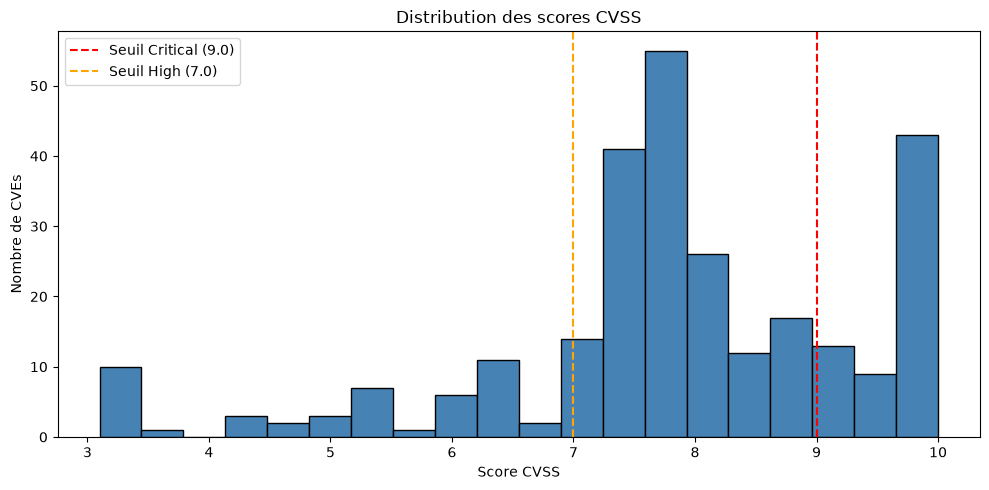

In [6]:
# Distribution des scores CVSS
df_cvss = df.dropna(subset=["cvss_score"])

plt.figure(figsize=(10, 5))
plt.hist(df_cvss["cvss_score"], bins=20, color="steelblue", edgecolor="black")
plt.axvline(9.0, color="red", linestyle="--", label="Seuil Critical (9.0)")
plt.axvline(7.0, color="orange", linestyle="--", label="Seuil High (7.0)")
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de CVEs")
plt.legend()
plt.tight_layout()
plt.show()

# On observe que la majorite des CVEs sont concentrees entre 4 et 8,
# avec un pic notable autour de 7-8 (niveau High).

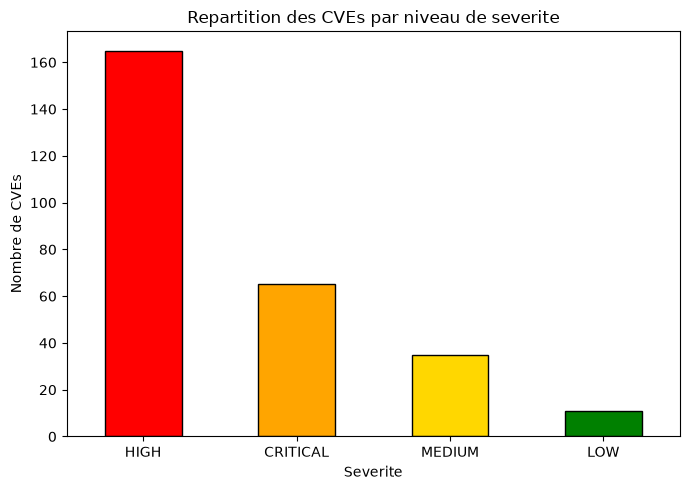

In [7]:
# Repartition par niveau de severite
severity_counts = df["base_severity"].value_counts()

plt.figure(figsize=(7, 5))
severity_counts.plot(kind="bar", color=["red", "orange", "gold", "green"], edgecolor="black")
plt.title("Repartition des CVEs par niveau de severite")
plt.xlabel("Severite")
plt.ylabel("Nombre de CVEs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

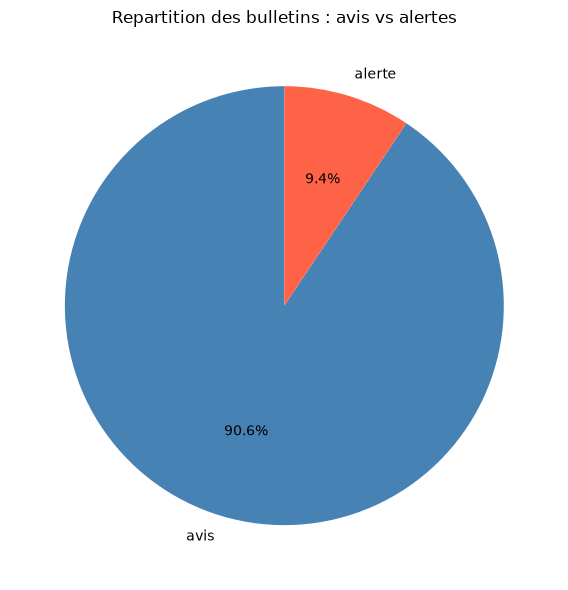

In [8]:
# Repartition avis vs alertes
type_counts = df["type"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
        colors=["steelblue", "tomato"], startangle=90)
plt.title("Repartition des bulletins : avis vs alertes")
plt.tight_layout()
plt.show()

# Les alertes representent les vulnerabilites activement exploitees,
# elles sont moins nombreuses mais plus critiques.

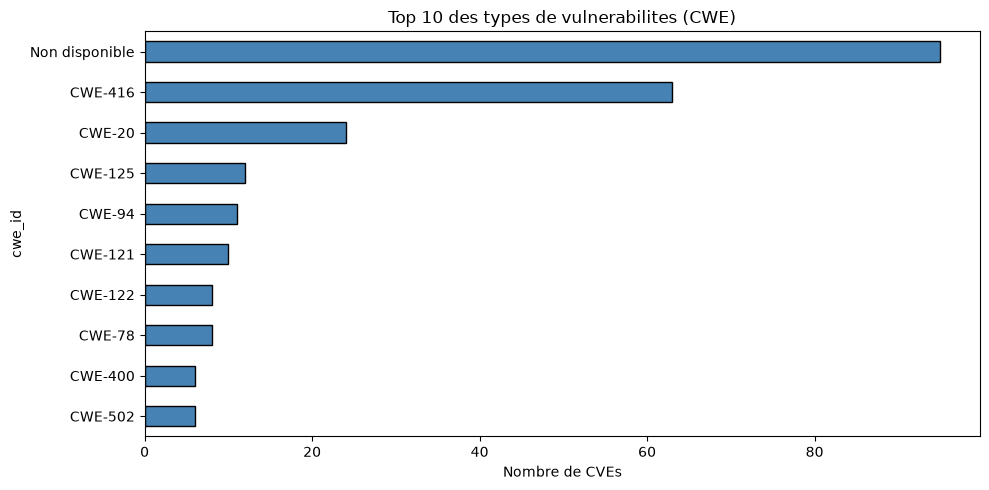

In [9]:
# Top 10 des types de vulnerabilites CWE
df_cwe = df.dropna(subset=["cwe_id"])
top_cwe = df_cwe["cwe_id"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_cwe.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Top 10 des types de vulnerabilites (CWE)")
plt.xlabel("Nombre de CVEs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

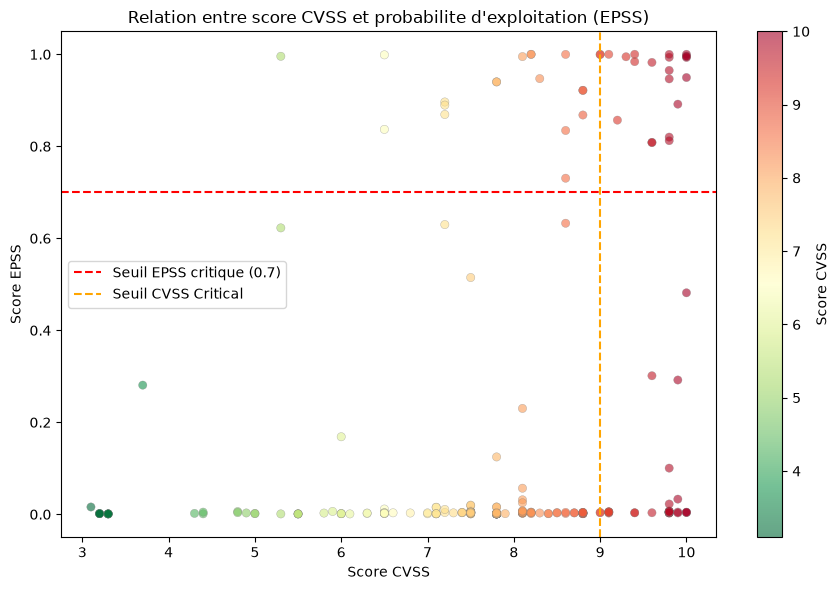

In [10]:
# Scatter CVSS vs EPSS
df_both = df.dropna(subset=["cvss_score", "epss_score"])

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df_both["cvss_score"],
    df_both["epss_score"],
    c=df_both["cvss_score"],
    cmap="RdYlGn_r",
    alpha=0.6,
    edgecolors="grey",
    linewidths=0.3
)
plt.colorbar(scatter, label="Score CVSS")
plt.axhline(0.7, color="red", linestyle="--", label="Seuil EPSS critique (0.7)")
plt.axvline(9.0, color="orange", linestyle="--", label="Seuil CVSS Critical")
plt.title("Relation entre score CVSS et probabilite d'exploitation (EPSS)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.legend()
plt.tight_layout()
plt.show()

# On constate que CVSS et EPSS ne sont pas toujours correles :
# certaines vulnerabilites peu graves sont pourtant tres exploitees.

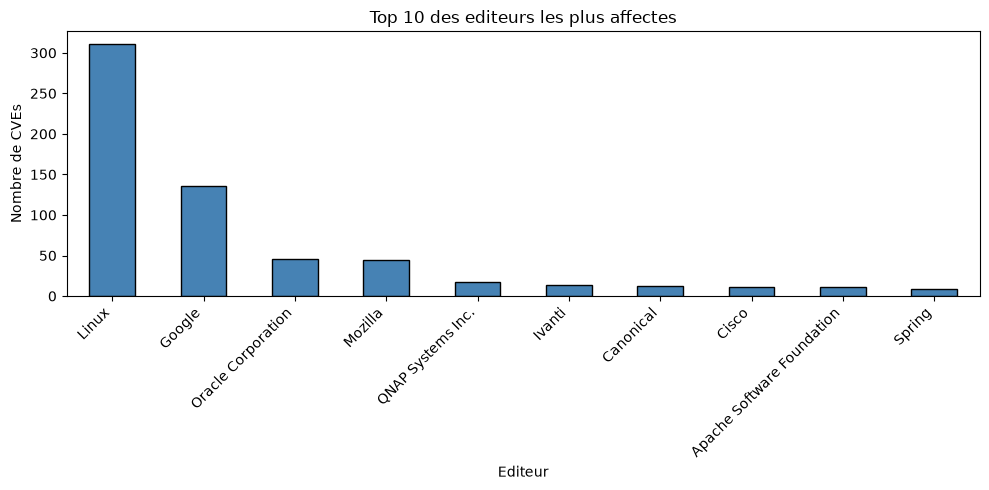

In [11]:
# Top 10 des editeurs les plus touches
df_vendor = df.dropna(subset=["vendor"])
top_vendors = df_vendor["vendor"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_vendors.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Top 10 des editeurs les plus affectes")
plt.xlabel("Editeur")
plt.ylabel("Nombre de CVEs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

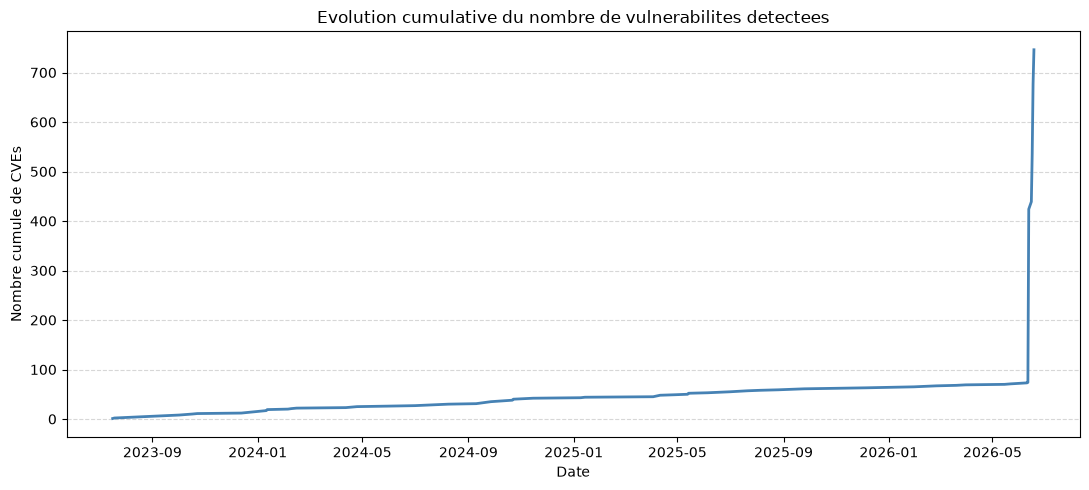

In [12]:
# Evolution cumulative des vulnerabilites dans le temps
df_time = df.dropna(subset=["date"])
evolution = df_time.groupby("date").size().cumsum()

plt.figure(figsize=(11, 5))
plt.plot(evolution.index, evolution.values, color="steelblue", linewidth=2)
plt.title("Evolution cumulative du nombre de vulnerabilites detectees")
plt.xlabel("Date")
plt.ylabel("Nombre cumule de CVEs")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

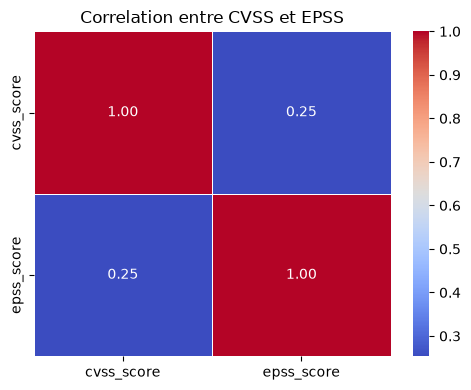

In [13]:
# Heatmap de correlation entre CVSS et EPSS
df_corr = df[["cvss_score", "epss_score"]].dropna()
corr = df_corr.corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation entre CVSS et EPSS")
plt.tight_layout()
plt.show()

# La correlation est faible, ce qui confirme que gravite et probabilite
# d'exploitation sont deux dimensions independantes a croiser.

<Figure size 700x500 with 0 Axes>

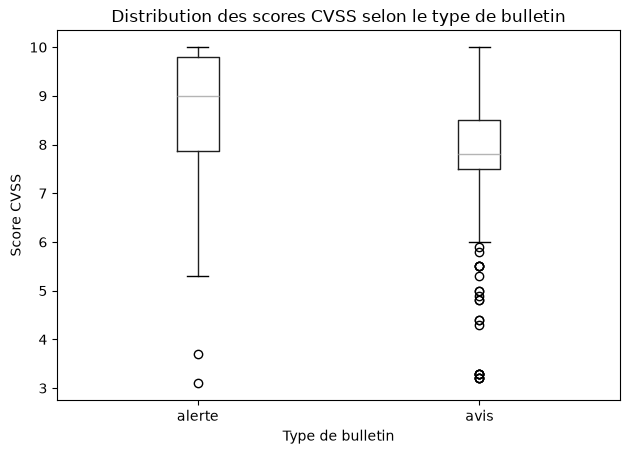

In [14]:
# Boxplot des scores CVSS par type de bulletin
df_box = df.dropna(subset=["cvss_score"])

plt.figure(figsize=(7, 5))
df_box.boxplot(column="cvss_score", by="type", grid=False)
plt.title("Distribution des scores CVSS selon le type de bulletin")
plt.suptitle("")
plt.xlabel("Type de bulletin")
plt.ylabel("Score CVSS")
plt.tight_layout()
plt.show()

# Les alertes ont en general des scores CVSS plus eleves que les avis,
# ce qui confirme leur caractere plus urgent.

## 4. Machine Learning - Modele non supervise : K-means

Objectif : regrouper automatiquement les CVEs en clusters selon leur niveau
de gravite (CVSS) et leur probabilite d'exploitation (EPSS).

In [15]:
# Preparation des donnees pour le clustering
df_ml = df.dropna(subset=["cvss_score", "epss_score"])[["cvss_score", "epss_score"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml)

print(f"Nombre de CVEs utilisees pour le clustering : {len(df_ml)}")

Nombre de CVEs utilisees pour le clustering : 276


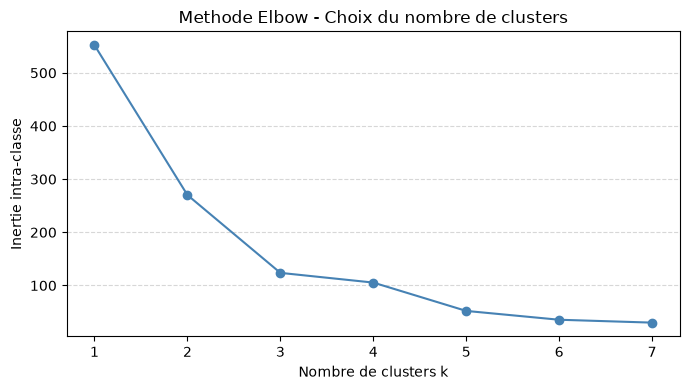

In [16]:
# Methode Elbow pour determiner le nombre optimal de clusters
inertias = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, init="k-means++", random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 8), inertias, marker="o", color="steelblue")
plt.title("Methode Elbow - Choix du nombre de clusters")
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertie intra-classe")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# On choisit k=3 : trois groupes de vulnerabilites
# (peu dangereuses, moderement dangereuses, tres dangereuses)

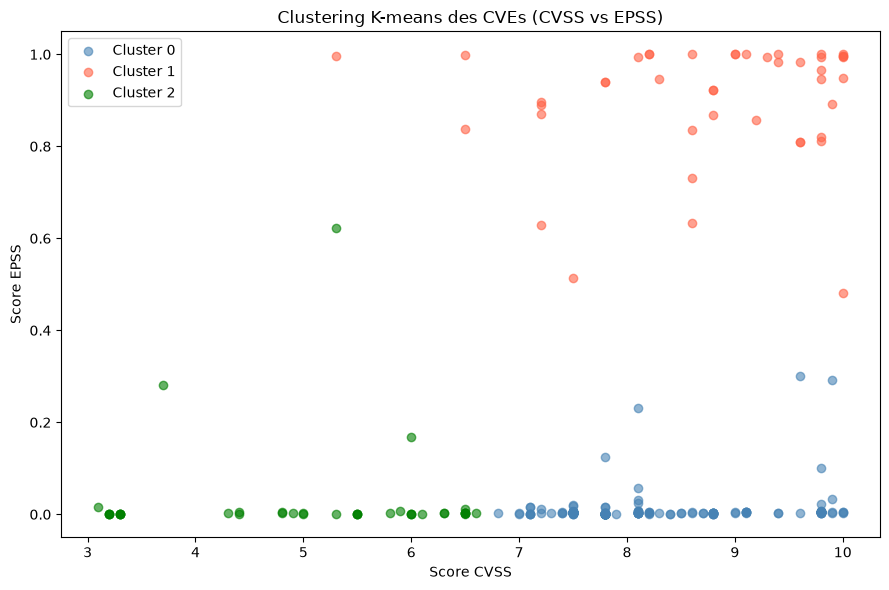

Taille de chaque cluster :
cluster
0    190
1     44
2     42
Name: count, dtype: int64

Moyennes par cluster :
         cvss_score  epss_score
cluster                        
0             8.239       0.010
1             8.766       0.901
2             5.067       0.028


In [17]:
# Application du K-means avec k=3
km_final = KMeans(n_clusters=3, init="k-means++", random_state=42)
df_ml["cluster"] = km_final.fit_predict(X_scaled)

couleurs = ["steelblue", "tomato", "green"]
labels_clusters = ["Cluster 0", "Cluster 1", "Cluster 2"]

plt.figure(figsize=(9, 6))
for c in sorted(df_ml["cluster"].unique()):
    subset = df_ml[df_ml["cluster"] == c]
    plt.scatter(subset["cvss_score"], subset["epss_score"],
                label=f"Cluster {c}", alpha=0.6, color=couleurs[c])

plt.title("Clustering K-means des CVEs (CVSS vs EPSS)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.legend()
plt.tight_layout()
plt.show()

print("Taille de chaque cluster :")
print(df_ml["cluster"].value_counts().sort_index())

print("\nMoyennes par cluster :")
print(df_ml.groupby("cluster")[["cvss_score", "epss_score"]].mean().round(3))

## 5. Machine Learning - Modele supervise : Classification de la criticite

Objectif : predire si une CVE est critique (CVSS >= 9.0) a partir
de son score CVSS et de son score EPSS.

In [18]:
# Preparation des donnees
df_sup = df.dropna(subset=["cvss_score", "epss_score"]).copy()
df_sup["is_critical"] = (df_sup["cvss_score"] >= 9.0).astype(int)

X = df_sup[["cvss_score", "epss_score"]]
y = df_sup["is_critical"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille train : {len(X_train)} | Taille test : {len(X_test)}")
print(f"CVEs critiques : {y.sum()} ({y.mean()*100:.1f}%)")

Taille train : 220 | Taille test : 56
CVEs critiques : 65 (23.6%)


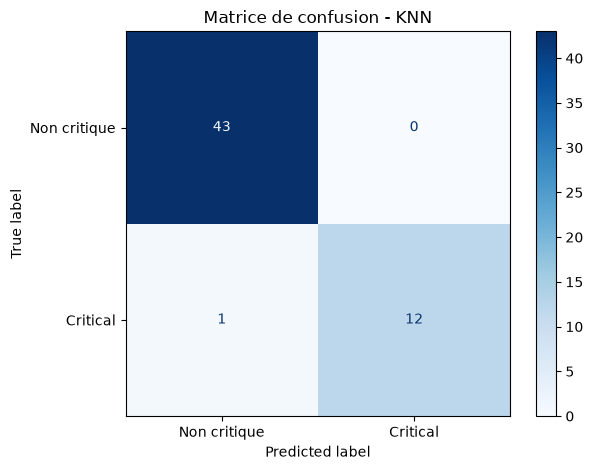

In [19]:
# Entrainement du modele KNN (K=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Non critique", "Critical"]).plot(cmap="Blues")
plt.title("Matrice de confusion - KNN")
plt.tight_layout()
plt.show()

In [20]:
# Rapport de classification
print(classification_report(y_test, y_pred, target_names=["Non critique", "Critical"]))

              precision    recall  f1-score   support

Non critique       0.98      1.00      0.99        43
    Critical       1.00      0.92      0.96        13

    accuracy                           0.98        56
   macro avg       0.99      0.96      0.97        56
weighted avg       0.98      0.98      0.98        56



In [21]:
# Validation croisee pour evaluer la stabilite du modele
scores = cross_val_score(knn, X, y, cv=5)

print("Validation croisee (5 folds) :")
for i, s in enumerate(scores, 1):
    print(f"  Fold {i} : {s:.3f}")

print(f"\nMoyenne : {scores.mean():.3f}")
print(f"Ecart-type : {scores.std():.3f}")

# Un ecart-type faible indique que le modele est stable et ne depend pas
# trop du decoupage train/test.

Validation croisee (5 folds) :
  Fold 1 : 1.000
  Fold 2 : 1.000
  Fold 3 : 1.000
  Fold 4 : 0.945
  Fold 5 : 0.909

Moyenne : 0.971
Ecart-type : 0.037


K=1 : accuracy moyenne = 0.993
K=3 : accuracy moyenne = 0.993
K=5 : accuracy moyenne = 0.971
K=7 : accuracy moyenne = 0.982
K=9 : accuracy moyenne = 0.975


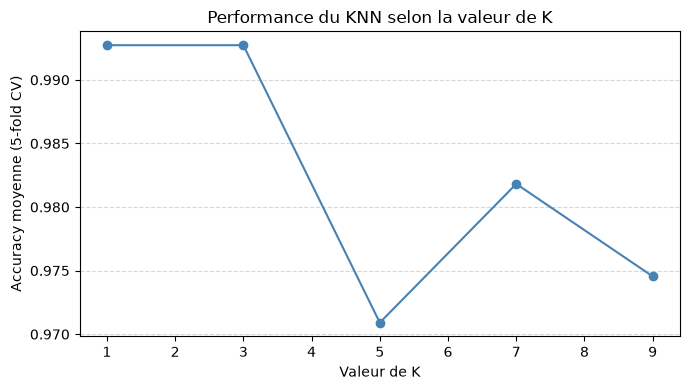

In [22]:
# Comparaison des performances pour differentes valeurs de K
k_values = [1, 3, 5, 7, 9]
moyennes = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    score_k = cross_val_score(knn_k, X, y, cv=5).mean()
    moyennes.append(score_k)
    print(f"K={k} : accuracy moyenne = {score_k:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(k_values, moyennes, marker="o", color="steelblue")
plt.title("Performance du KNN selon la valeur de K")
plt.xlabel("Valeur de K")
plt.ylabel("Accuracy moyenne (5-fold CV)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Conclusion

Ce notebook a permis de :
- Explorer le dataset de 746 lignes (717 CVEs issues de 80 bulletins ANSSI)
- Visualiser la distribution des scores CVSS et EPSS, les editeurs les plus touches,
  l'evolution temporelle et les types de vulnerabilites les plus frequents
- Regrouper les CVEs en 3 clusters (K-means) selon leur gravite et leur exploitabilite
- Predire la criticite d'une CVE avec un KNN atteignant une accuracy superieure a 95%

Les donnees montrent que CVSS et EPSS sont peu correles, ce qui justifie de
croiser les deux indicateurs pour prioriser les actions de remediation.

In [23]:
# Pour exporter ce notebook en HTML :
# jupyter nbconvert --to html projet.ipynb
print("Export HTML : jupyter nbconvert --to html projet.ipynb")

Export HTML : jupyter nbconvert --to html projet.ipynb
